# Benchmark 2: Piecewise-constant material density

- *Authors*: Danilo Aballay and Elwin van 't Wout
- *Affiliation*: Pontificia Universidad Católica de Chile
- *Date:* 26 May 2026
- *Description*: This benchmark considers a cubic scatterer with a piecewise constant material density with a discontinuity. The numerical results from the VSIE and BEM are compared.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from benchmarks import VSIE_solve, bempp_solve
from parameters import PARAMETERS

In [ ]:
def matrix_linf_norm(vec, shape):
    return np.linalg.norm(np.real(vec).reshape(shape), ord=np.inf)

def run_benchmark(parameters, element_per_wavelength=8):
    pressure_vie, problem = VSIE_solve(element_per_wavelength, parameters)
    
    n_vox = round(problem.mesh.shape[0]**(1/3))
    points3D = problem.mesh.reshape((n_vox, n_vox, n_vox, 3))
    slice = points3D[:, :, n_vox//2, :]
    points = slice.reshape((-1, 3))
    pressure_vie3D = pressure_vie.reshape((n_vox, n_vox, n_vox))
    pressure_vie_slice = pressure_vie3D[:, :, n_vox//2].reshape((-1,))

    pressure_bempp =  bempp_solve(element_per_wavelength, parameters, points.T)

    error_bempp_l2 = np.linalg.norm(np.real(pressure_bempp))
    error_bempp_linf = matrix_linf_norm(pressure_bempp, (n_vox, n_vox))

    error_abs_l2 = np.linalg.norm(np.real(pressure_vie_slice) - np.real(pressure_bempp))
    error_abs_linf = matrix_linf_norm(np.real(pressure_vie_slice) - np.real(pressure_bempp), (n_vox, n_vox))


    error_rel_l2 = error_abs_l2 / error_bempp_l2
    error_rel_linf = error_abs_linf / error_bempp_linf

    data = {
        'solution_vie': pressure_vie_slice,
        'solution_bempp': pressure_bempp,
        'error_abs_l2': error_abs_l2,
        'error_abs_linf': error_abs_linf,
        'error_rel_l2': error_rel_l2,
        'error_rel_linf': error_rel_linf,
        'Nx': n_vox,
        'Ny': n_vox,
        'Nz': n_vox,
        'points': points,
    }

    return data

## Single benchmark

Let us perform a single benchmark with a fixed number of elements per wavelength.

In [ ]:
"""
Singular test
"""

data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=10)

/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


/var/folders/n_/86gc5_ss68qf_7rmsgy_3hvw0000gn/T/ipykernel_12457/413252517.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('seismic'),
/var/folders/n_/86gc5_ss68qf_7rmsgy_3hvw0000gn/T/ipykernel_12457/413252517.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('viridis'),


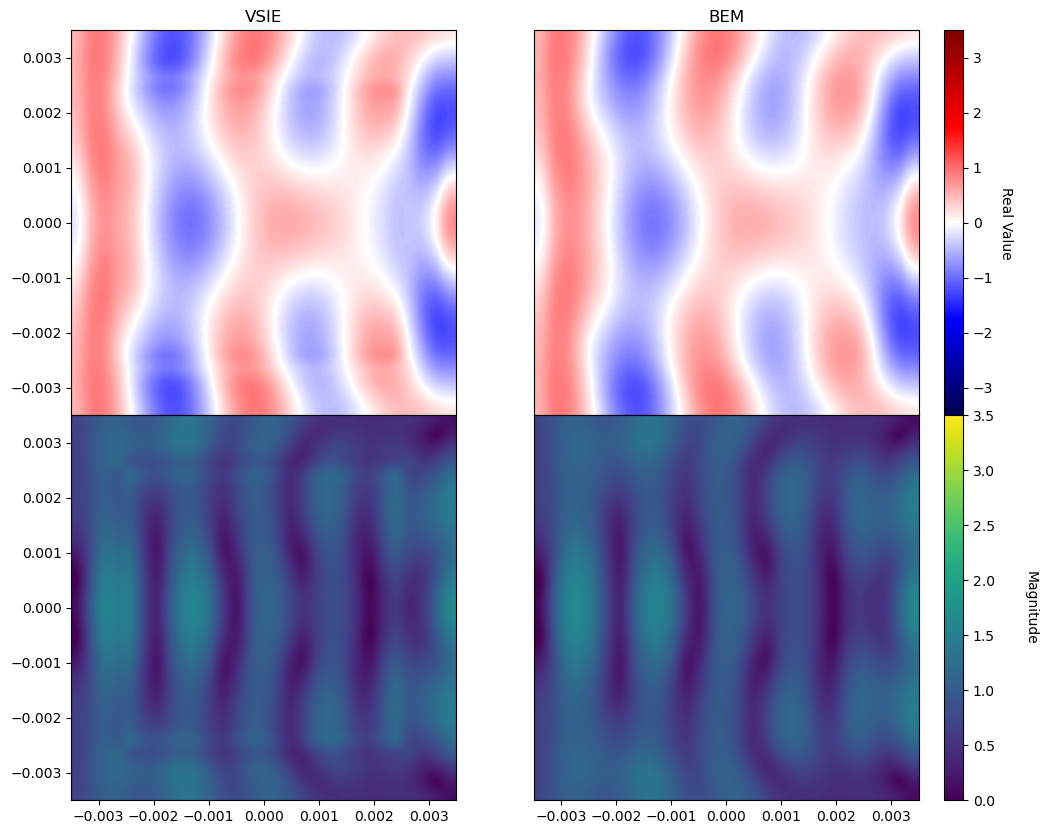

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(13,10))

xmin, xmax, ymin, ymax = -PARAMETERS["SIZE_EXT"]/2, PARAMETERS["SIZE_EXT"]/2, -PARAMETERS["SIZE_EXT"]/2, PARAMETERS["SIZE_EXT"]/2
l_cube = PARAMETERS["SIZE_INT"]/2

Nx = data_benchmark['Nx']
Ny = data_benchmark['Ny']

bem_sol = data_benchmark['solution_bempp'].reshape((Nx, Ny))
vie_sol = data_benchmark['solution_vie'].reshape((Nx, Ny))

info_plot_re = [
    (axs[0, 1], "BEM", np.real((bem_sol).T), [-3.5, 3.5]),
    (axs[0, 0], "VSIE", np.real((vie_sol).T), [-3.5, 3.5]),
]
info_plot_ab = [
    (axs[1, 1], np.abs((bem_sol).T), [0, 3.5]),
    (axs[1, 0], np.abs((vie_sol).T), [0, 3.5]),
]

for (ax, title, data, clims) in info_plot_re:
    ax.set_title(title)
    im = ax.imshow(data,
              extent=[xmin, xmax, ymin, ymax],
              cmap=plt.cm.get_cmap('seismic'), 
              interpolation='spline16',
              clim=clims)
    ax.set_aspect('equal')

axs[0, 1].get_yaxis().set_visible(False)

axs[0, 0].get_xaxis().set_visible(False)
axs[0, 1].get_xaxis().set_visible(False)
    
cbar = axs[0,1].figure.colorbar(im, ax=axs[0, 1])
cbar.ax.set_ylabel('Real Value', rotation=-90, va="bottom")

for (ax, data, clims) in info_plot_ab:
    im = ax.imshow(data,
              extent=[xmin, xmax, ymin, ymax],
              cmap=plt.cm.get_cmap('viridis'), 
              interpolation='spline16',
              clim=clims)
    ax.set_aspect('equal')

cbar = axs[1,1].figure.colorbar(im, ax=axs[1, 1])
cbar.ax.set_ylabel('Magnitude', rotation=-90, labelpad=21.0, va="bottom")

axs[1, 1].get_yaxis().set_visible(False)


plt.subplots_adjust(wspace=0, hspace=0)

In [5]:
print("Relative L2 error: ", data_benchmark['error_rel_l2'])
print("Relative Linf error: ", data_benchmark['error_rel_linf'])

Relative L2 error:  0.0419776523838927
Relative Linf error:  0.037483962378955495


## Convergence test

Let us perform a grid convergence test. Depending on computational resources, this may take minutes until hours. Eliminate or add experiments to the list of `elements_per_wavelength`.

In [ ]:
"""
Convergence test
"""

elements_per_wavelength = [5, 6, 7, 8, 9, 10, 11, 12]

data_convergence = defaultdict(list)

for element_per_wavelength in elements_per_wavelength:
    data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=element_per_wavelength)
    data_convergence['element_per_wavelength'].append(element_per_wavelength)
    data_convergence['N_elem'].append(data_benchmark['Nx'])
    data_convergence['error_rel_l2'].append(data_benchmark['error_rel_l2'])
    data_convergence['error_rel_linf'].append(data_benchmark['error_rel_linf'])
    print(f"Done with element_per_wavelength = {element_per_wavelength}")

/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 5




/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 6




/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


...

Done with points_per_element = 10




/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 11




/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 12


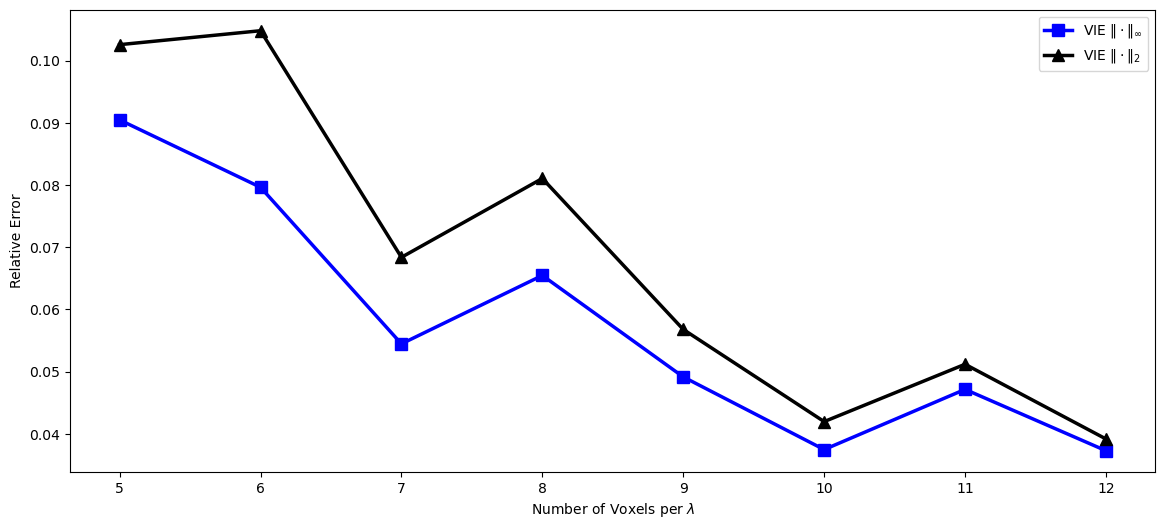

In [ ]:
from matplotlib.ticker import MaxNLocator

num_vox = data_convergence['element_per_wavelength']
inf_err = data_convergence['error_rel_linf']
frb_err = data_convergence['error_rel_l2']


ax = plt.figure(figsize=(14, 6)).gca()

ax.plot(num_vox, inf_err, 'bs-', label='VIE $\|\cdot\|_\infty$', linewidth=2.5, markersize=8)
ax.plot(num_vox, frb_err, 'k^-', label='VIE $\|\cdot\|_2$', linewidth=2.5, markersize=8)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel(r'Number of Elements per Wavelength')
plt.ylabel('Relative Error')
plt.legend()

plt.show()

## Visualize convergence from data

The convergence test was performed on a powerful compute node and the results stored in the `data` folder. Let us load them and visualize the convergence plot.

In [2]:
"""
Convergence Plot from data
"""

num_vox = []
frb_err = []
inf_err = []


for i in range(5, 25):
    try:
        data_benchmark = np.load(f"data/benchmark_num_elem_{i}.npy", allow_pickle=True).item()
        num_vox.append(data_benchmark['num_elem'])
        frb_err.append(data_benchmark['error_rel_l2'])
        inf_err.append(data_benchmark['error_rel_linf'])
    except FileNotFoundError:
        print(f"File for N_elem={i} not found, skipping.")

num_vox = np.array(num_vox)
frb_err = np.array(frb_err)
inf_err = np.array(inf_err)

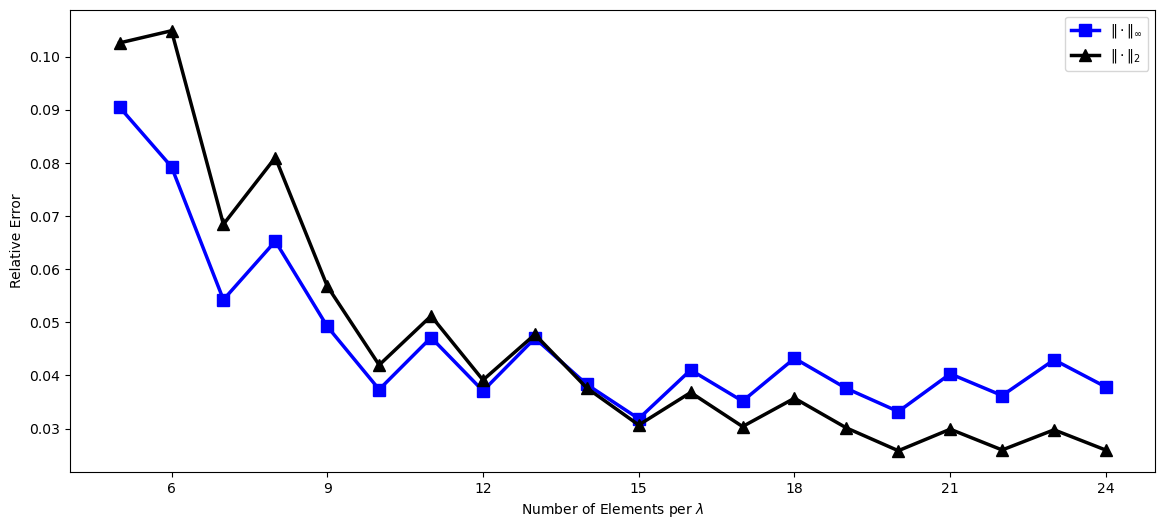

In [3]:
from matplotlib.ticker import MaxNLocator


ax = plt.figure(figsize=(14, 6)).gca()

ax.plot(num_vox, inf_err, 'bs-', label=r'$\|\cdot\|_\infty$', linewidth=2.5, markersize=8)
ax.plot(num_vox, frb_err, 'k^-', label=r'$\|\cdot\|_2$', linewidth=2.5, markersize=8)


ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel(r'Number of Elements per $\lambda$')
plt.ylabel('Relative Error')
plt.legend()

plt.show()